<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully created!
Shape: (1500, 7)
   TV_Budget  Radio_Budget  Newspaper_Budget  Discount_Pct  Store_Footfall  \
0     118.62         28.36             53.82             0            2409   
1     285.71         26.56             63.73            15            1038   
2     222.28          6.15             20.04             0            1289   
3     183.61         20.36             49.99             5            1293   
4      55.25         22.11             45.74             0            2169   

   Is_Holiday  Sales  
0           1  53.54  
1           1  47.39  
2           0  32.71  
3           0  40.25  
4           0  41.08  


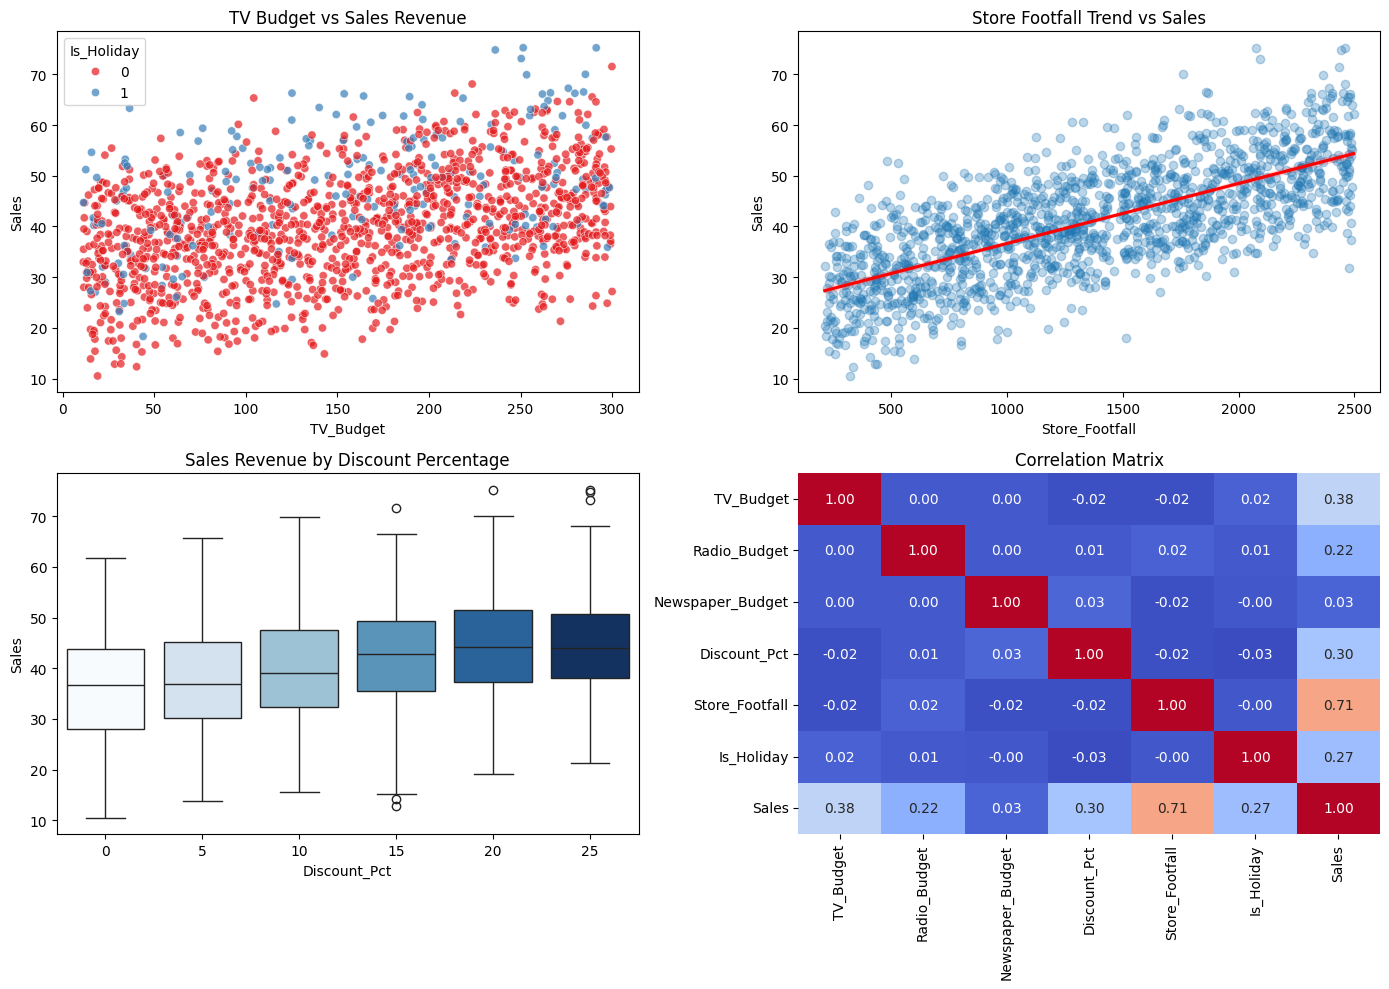

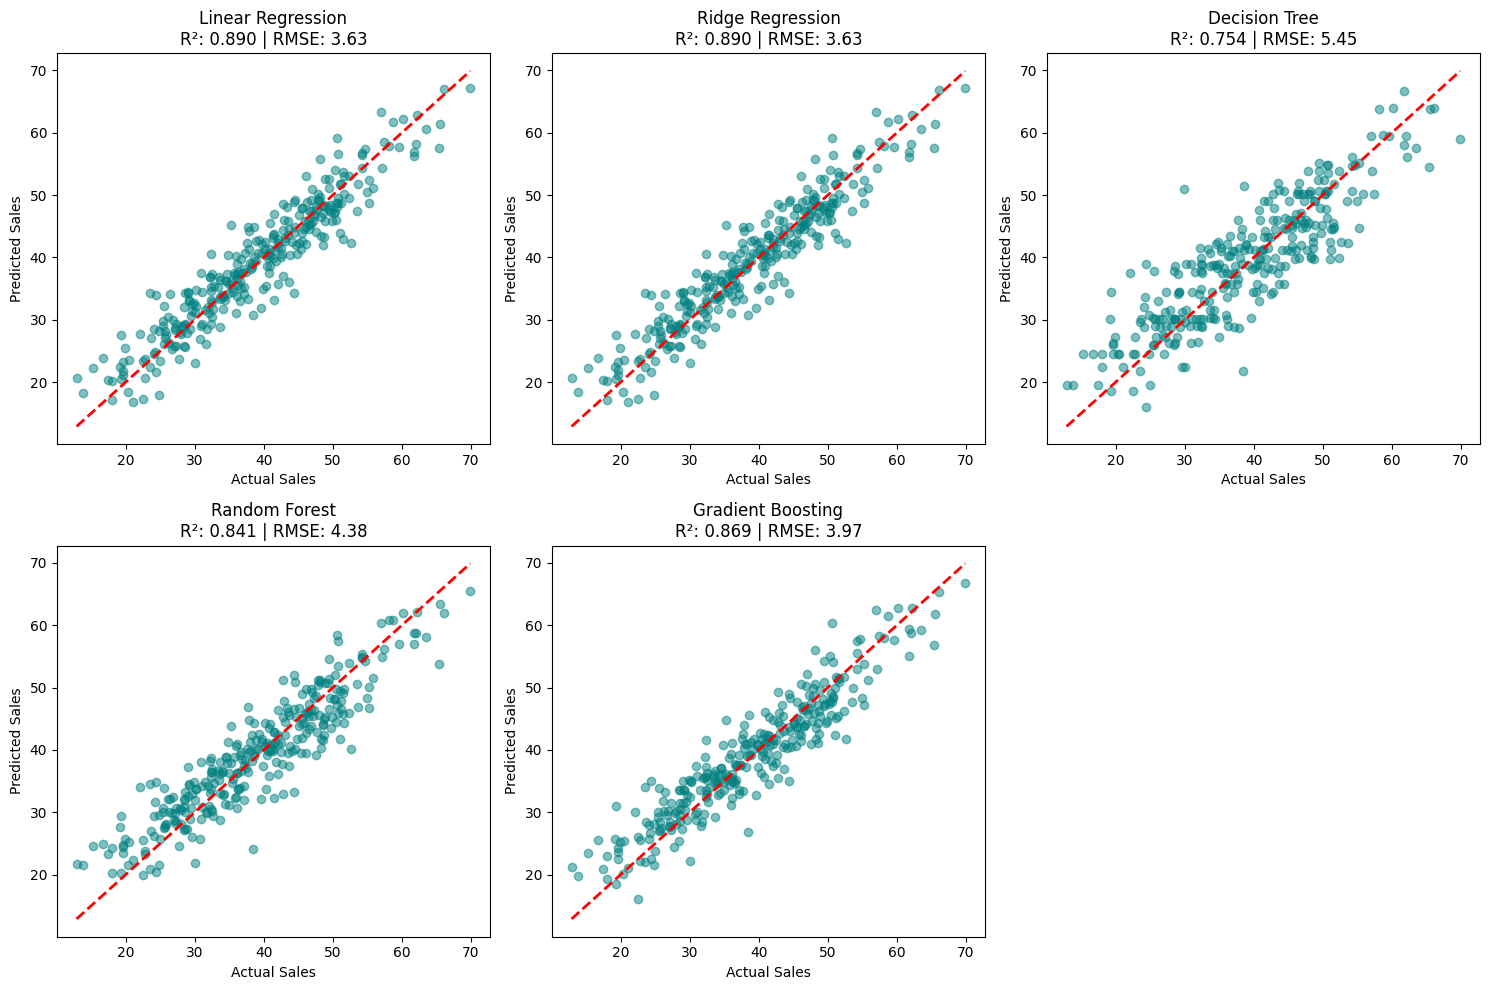

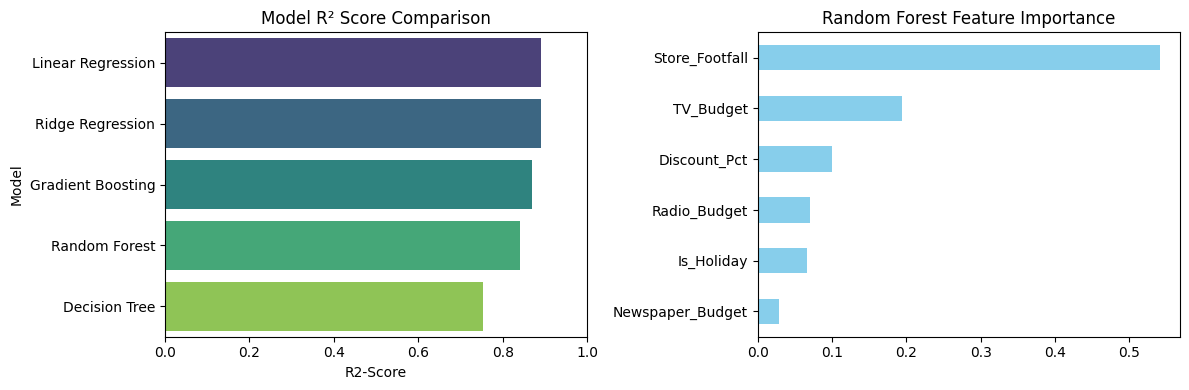


=== SALES PREDICTION PERFORMANCE RANKING ===
            Model  R2-Score      MAE     RMSE
Linear Regression  0.890476 2.826957 3.634208
 Ridge Regression  0.890466 2.827386 3.634366
Gradient Boosting  0.869303 3.128895 3.969962
    Random Forest  0.840661 3.524450 4.383439
    Decision Tree  0.753557 4.322601 5.451457


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE REALISTIC SALES DATASET
# ==========================================
np.random.seed(42)
n_samples = 1500

tv_budget = np.random.uniform(10, 300, n_samples)
radio_budget = np.random.uniform(5, 50, n_samples)
newspaper_budget = np.random.uniform(0, 80, n_samples)
discount_pct = np.random.choice([0, 5, 10, 15, 20, 25], n_samples)
store_footfall = np.random.randint(200, 2500, n_samples)
is_holiday = np.random.choice([0, 1], n_samples, p=[0.85, 0.15])

# Calculate target variable 'Sales' (in thousands of dollars) with non-linear relationships and noise
sales = (
    5.0
    + 0.05 * tv_budget
    + 0.18 * radio_budget
    + 0.02 * newspaper_budget
    + 0.012 * store_footfall
    + 0.4 * discount_pct
    + 8.5 * is_holiday
    + np.random.normal(0, 3.5, n_samples)
)

df = pd.DataFrame({
    'TV_Budget': tv_budget.round(2),
    'Radio_Budget': radio_budget.round(2),
    'Newspaper_Budget': newspaper_budget.round(2),
    'Discount_Pct': discount_pct,
    'Store_Footfall': store_footfall,
    'Is_Holiday': is_holiday,
    'Sales': sales.round(2)
})

print("Dataset successfully created!")
print(f"Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: TV Budget vs Sales
plt.subplot(2, 2, 1)
sns.scatterplot(x="TV_Budget", y="Sales", data=df, hue="Is_Holiday", palette="Set1", alpha=0.7)
plt.title("TV Budget vs Sales Revenue")

# Graph 2: Store Footfall vs Sales
plt.subplot(2, 2, 2)
sns.regplot(x="Store_Footfall", y="Sales", data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Store Footfall Trend vs Sales")

# Graph 3: Discount Impact on Sales
plt.subplot(2, 2, 3)
sns.boxplot(x="Discount_Pct", y="Sales", data=df, hue="Discount_Pct", palette="Blues", legend=False)
plt.title("Sales Revenue by Discount Percentage")

# Graph 4: Feature Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & SPLITTING
# ==========================================
X = df.drop(columns=["Sales"])
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & REGRESSION EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=8),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": name, "R2-Score": r2, "MAE": mae, "RMSE": rmse})

    # Plot Actual vs Predicted
    axes[idx].scatter(y_test, y_pred, alpha=0.5, color='teal')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: {rmse:.2f}")
    axes[idx].set_xlabel("Actual Sales")
    axes[idx].set_ylabel("Predicted Sales")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: R2 Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="R2-Score", y="Model", data=results_df, hue="Model", palette="viridis", legend=False)
plt.title("Model R² Score Comparison")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Random Forest
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="skyblue")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== SALES PREDICTION PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))